# Model Training

**Pipeline:**

1. ColumnTransformer encoding:

   * Categorical columns → OneHotEncoder
   * Numerical columns → passthrough
2. Train/test split 80/20
3. Loop through models: **XGBoost + LightGBM**
4. Use sample weights to compensate for class imbalance

**Displayed metrics:**

* Overall accuracy
* Classification report (precision, recall, f1-score per class)
* Confusion matrix (to visualize false positives/negatives)



In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
from lightgbm import LGBMClassifier
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

In [5]:
df_final = pd.read_csv("../front/data/accidents_clean.csv")
df_final.head()

,Num_Acc,grav_accident,nb_usagers,nb_vehicules,is_passagers,is_pietons,place,age_cat,nb_proteges,trajet,...,nbv,vma,lum,dep,agg,int,atm,col,is_weekend,saison
0,202100000001,2.0,2,2,0,0,1.0,18-64,2,1.0,...,2.0,80.0,2.0,30,1,1.0,1.0,1.0,0,automne
1,202100000002,2.0,2,2,0,0,1.0,18-64,2,0.0,...,2.0,80.0,1.0,51,1,3.0,1.0,3.0,1,automne
2,202100000003,2.0,2,1,0,0,1.0,18-64,1,1.0,...,2.0,50.0,1.0,85,2,1.0,7.0,6.0,0,ete
3,202100000004,3.0,2,2,0,0,1.0,12-17,1,5.0,...,4.0,50.0,5.0,93,2,2.0,3.0,6.0,1,printemps
4,202100000005,1.0,2,2,0,0,1.0,18-64,2,1.0,...,2.0,50.0,5.0,76,2,1.0,1.0,2.0,0,hiver


In [6]:
df_final.columns

Index(['Num_Acc', 'grav_accident', 'nb_usagers', 'nb_vehicules',
       'is_passagers', 'is_pietons', 'place', 'age_cat', 'nb_proteges',
       'trajet', 'sexe', 'pres_femme', 'localisation_pieton', 'catr', 'circ',
       'surf', 'infra', 'situ', 'nbv', 'vma', 'lum', 'dep', 'agg', 'int',
       'atm', 'col', 'is_weekend', 'saison'],
      dtype='str')

In [7]:
from sklearn.preprocessing import LabelEncoder

X = df_final.drop(columns=['grav_accident', 'Num_Acc'])
le = LabelEncoder()
y_encoded = le.fit_transform(df_final['grav_accident'])

cat_cols = ['place', 'age_cat','trajet', 'sexe', 'localisation_pieton', 'catr', 'circ', 'surf', 'infra', 'situ', 'lum', 'dep', 'agg', 'int','atm', 'col', 'saison']
num_cols = [c for c in X.columns if c not in cat_cols]


preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state = 42)

In [8]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(176835, 26) (44209, 26) (176835,) (44209,)



======= XGBoost =======


C:\Users\ins expertise\anaconda3\envs\app\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:09:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.6312

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.72      0.78     28333
           1       0.49      0.44      0.47     13323
           2       0.19      0.59      0.29      2553

    accuracy                           0.63     44209
   macro avg       0.51      0.58      0.51     44209
weighted avg       0.70      0.63      0.66     44209



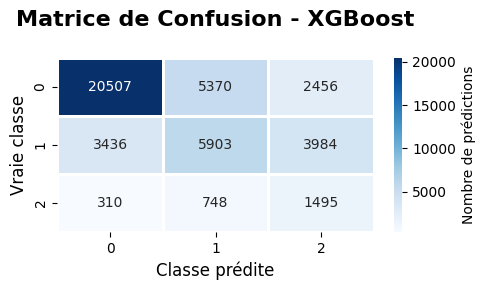


======= LightGBM =======
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028757 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 530
[LightGBM] [Info] Number of data points in the train set: 176835, number of used features: 214
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


C:\Users\ins expertise\anaconda3\envs\app\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.6260

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.72      0.78     28333
           1       0.49      0.42      0.45     13323
           2       0.18      0.62      0.28      2553

    accuracy                           0.63     44209
   macro avg       0.51      0.59      0.51     44209
weighted avg       0.70      0.63      0.65     44209



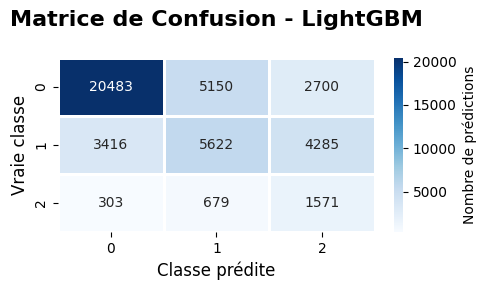

In [9]:

# 1) Dictionnaire de modèles
models = {
    "XGBoost": XGBClassifier( objective='multi:softprob', num_class=3,eval_metric='mlogloss',use_label_encoder=False),
    "LightGBM": LGBMClassifier()
}

# 2) Boucle avec pipeline
trained_pipelines = {}

target_names = ['0', '1', '2']

for name, model in models.items():
    print(f"\n======= {name} =======")

    pipe = Pipeline([
        ('preprocess', preprocess),
        ('model', model)
    ])

    weights = compute_sample_weight(class_weight='balanced', y=y_train)
    pipe.fit(X_train, y_train, model__sample_weight=weights)

    y_pred = pipe.predict(X_test)

    trained_pipelines[name] = pipe


    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names,
                cbar_kws={'label': 'Nombre de prédictions'},
                linewidths=2, linecolor='white')
    plt.title(f'Matrice de Confusion - {name}\n', fontsize=16, fontweight='bold')
    plt.ylabel('Vraie classe', fontsize=12)
    plt.xlabel('Classe prédite', fontsize=12)
    plt.tight_layout()
    plt.show()


##  Results Interpretation (multiclass classification)

### a) Overall summary
Both models (XGBoost and LightGBM) show an **accuracy around 0.63**, meaning the model correctly classifies about **63% of the samples**.

However, accuracy is not sufficient to evaluate performance in a **highly imbalanced multiclass setting**, since the majority class (0) dominates the score.

---

### b) Class-wise analysis

####  Class 0 (majority class)
- **Support: 28333**
- **Precision: 0.85**
- **Recall: 0.73**
- **F1-score: 0.78**

The model performs very well on class 0. It correctly identifies most non-severe cases, but still misses about **27% of them** (recall 0.73).

---

####  Class 1
- **Support: 13323**
- **Precision: 0.49**
- **Recall: 0.44**
- **F1-score: 0.47**

The model struggles to correctly classify class 1:
- less than half of true class 1 instances are detected (low recall),
- many predictions labeled as class 1 are incorrect (low precision).

---

####  Class 2 (minority class)
- **Support: 2553**
- **Precision: 0.19**
- **Recall: 0.59**
- **F1-score: 0.29**

The model shows a strong imbalance between precision and recall:
- recall is acceptable (0.59), meaning it detects more than half of the true class 2 cases,
- but precision is very low (0.19), indicating a large number of false positives.

This means the model predicts class 2 too often and incorrectly.

---

### c) Overall metrics

- **Macro avg**:  
  Precision = 0.51, Recall = 0.59, F1 = 0.51  
  → Performance on minority classes pulls the average down.

- **Weighted avg**:  
  Precision = 0.70, Recall = 0.63, F1 = 0.66  
  → Majority class dominates the score.

---

### d) Why class_weight did not fully solve the issue

You used `compute_sample_weight(class_weight='balanced')`, so each minority class is given a higher weight.  
However, despite weighting, classes 1 and 2 remain weak because:

1. The imbalance is still very strong (28k vs 2.5k)  
2. Tree-based models optimize a global loss, so they can still favor the majority class  
3. Class weighting rarely solves the problem alone—additional techniques are usually needed.

---

### e) Recommended 
To improve performance on classes 1 and 2, consider:

- Resampling (SMOTE / undersampling)
- Hyperparameter tuning using metrics like f1_macro or recall_macro
- Testing alternative objectives (focal loss, etc.)
- Threshold adjustment

---

### Conclusion
The model is strong for the majority class but struggles with classes 1 and 2.  
Class weighting helps but is not sufficient in this highly imbalanced scenario.


### 📈 ROC Curves (One-vs-Rest)

**For each class (0, 1, 2) and each model:**

* Plot the ROC curve: FPR vs. TPR
* AUC = area under the curve (0.5 = random, 1.0 = perfect)

**Interpretation:**

* **AUC close to 1.0**: the model discriminates well for that class
* **AUC ≈ 0.5**: the model does not discriminate; little predictive information

C:\Users\ins expertise\anaconda3\envs\app\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:10:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.026360 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 530
[LightGBM] [Info] Number of data points in the train set: 176835, number of used features: 214
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


C:\Users\ins expertise\anaconda3\envs\app\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


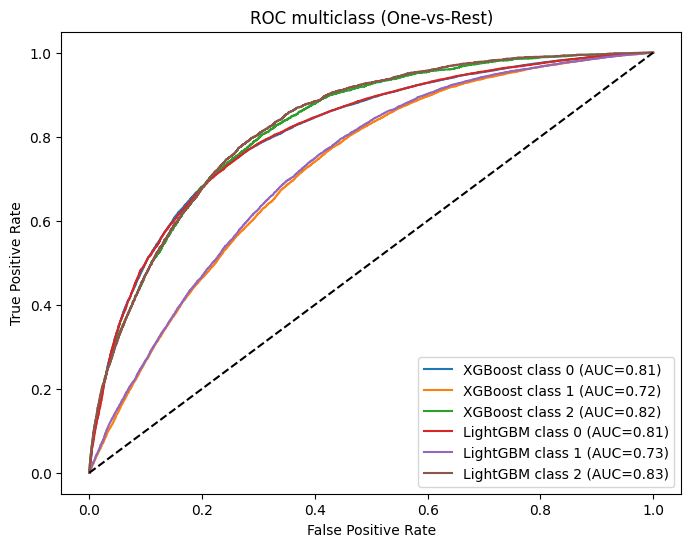

In [10]:
from sklearn.metrics import auc, roc_curve
from sklearn.preprocessing import label_binarize

# 1) binariser y_test
y_test_bin = label_binarize(y_test, classes=[0,1,2])

plt.figure(figsize=(8,6))

for name, model in models.items():
    pipe = Pipeline([
        ('preprocess', preprocess),
        ('model', model)
    ])

    weights = compute_sample_weight(class_weight='balanced', y=y_train)
    pipe.fit(X_train, y_train, model__sample_weight=weights)

    y_pred_proba = pipe.predict_proba(X_test)

    # ROC OVR
    for i in range(3):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} class {i} (AUC={roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC multiclass (One-vs-Rest)')
plt.legend()
plt.show()


# ROC Curve Analysis

##  Multiclass Classification (One-vs-Rest)

This ROC curve compares the performance of **XGBoost** and **LightGBM** for predicting 3 different classes using the One-vs-Rest approach.
!
**Key Observations:**

**Overall Performance:** Both models show very similar performance with high AUCs (0.73-0.83), indicating good discriminative ability.

**Class-by-Class Comparison:**
- **Class 0:** XGBoost (AUC=0.81) and LightGBM (AUC=0.81) are perfectly equivalent, with nearly overlapping curves
- **Class 1:** Both models show their weakest performance (AUC=0.73), suggesting this class is harder to distinguish, likely due to overlap with other classes
- **Class 2:** LightGBM (AUC=0.83) slightly outperforms XGBoost (AUC=0.82), making it the best-predicted class

**Interpretation:** Class 1 would likely benefit from additional feature engineering or data rebalancing to improve performance.


In [12]:
import joblib

joblib.dump(pipe, "../back/models/pipeline.pkl")
joblib.dump(le, "../back/models/label_encoder.pkl")


['../back/models/label_encoder.pkl']

In [13]:
#Choix du modèle
pipe = trained_pipelines["XGBoost"]
preprocessor = pipe.named_steps["preprocess"]
model = pipe.named_steps["model"]


In [14]:
#Transformer + noms de features
X_train_transformed = preprocessor.transform(X_train)

if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()

feature_names = preprocessor.get_feature_names_out()

X_train_transformed = pd.DataFrame(
    X_train_transformed,
    columns=feature_names
)

In [15]:
import shap

#Calcul SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train_transformed)

print("SHAP values type:", type(shap_values))
print("SHAP values shape:", np.array(shap_values).shape)

C:\Users\ins expertise\anaconda3\envs\app\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (176835, 217, 3)



📌 Classe 0 - Top 10 variables
vma             0.175286
catr            0.171590
saison          0.125281
lum             0.123910
nbv             0.123807
trajet          0.115375
is_weekend      0.112369
nb_usagers      0.108503
nb_vehicules    0.104468
atm             0.087880
dtype: float32


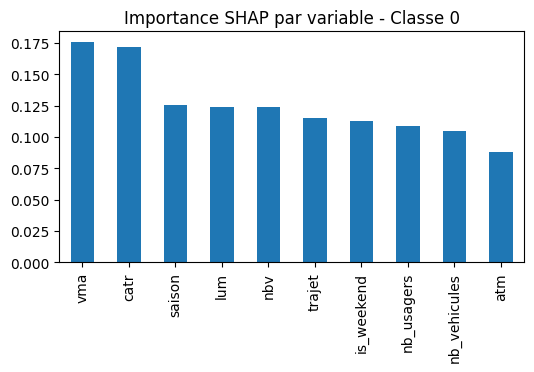


📌 Classe 1 - Top 10 variables
nb_proteges     0.530525
vma             0.285314
lum             0.189955
is_passagers    0.181301
col             0.150461
situ            0.144099
is_weekend      0.118727
nb_vehicules    0.101933
saison          0.095458
catr            0.091853
dtype: float32


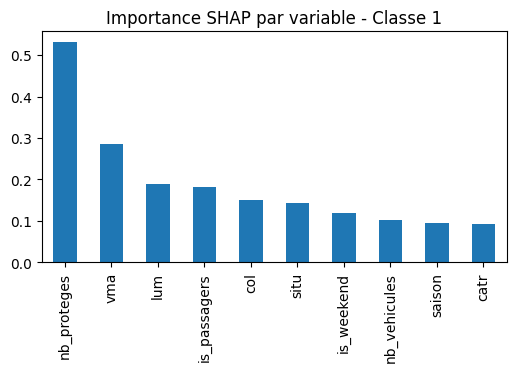


📌 Classe 2 - Top 10 variables
nb_proteges     0.262358
is_weekend      0.243737
lum             0.226785
vma             0.224366
saison          0.217617
circ            0.206931
nbv             0.179073
is_passagers    0.177228
col             0.165496
nb_vehicules    0.142932
dtype: float32


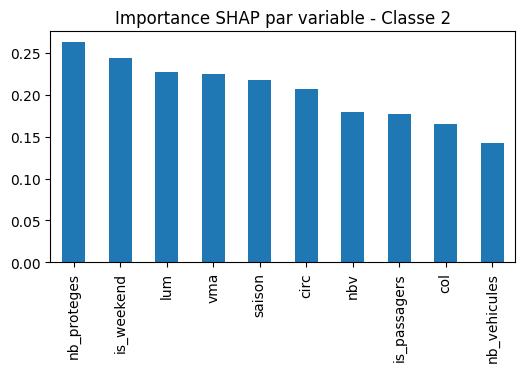

In [16]:

from collections import defaultdict

# ----- préparation -----
feature_names = preprocessor.get_feature_names_out()

def base_var(name):
    if name.startswith("cat__"):
        return name.split("__")[1].split("_")[0]
    if name.startswith("num__"):
        return name.split("__")[1]
    return name

# mapping variable -> indices encodées
group = defaultdict(list)
for i, col in enumerate(feature_names):
    group[base_var(col)].append(i)


# ----- calcul des importances par classe -----
def shap_imp_per_class(shap_values, class_idx):
    if isinstance(shap_values, list):
        sv = shap_values[class_idx]
    elif np.array(shap_values).ndim == 3:
        sv = shap_values[:, :, class_idx]
    else:
        raise ValueError("SHAP doit être une liste ou un tableau 3D.")

    return pd.Series(
        {var: np.mean(np.abs(sv[:, idxs])) for var, idxs in group.items()}
    ).sort_values(ascending=False)


# ----- affichage par classe -----
n_classes = len(shap_values) if isinstance(shap_values, list) else shap_values.shape[2]

for c in range(n_classes):
    print(f"\n📌 Classe {c} - Top 10 variables")
    imp = shap_imp_per_class(shap_values, c)
    print(imp.head(10))

    imp.head(10).plot(kind="bar", figsize=(6,3))
    plt.title(f"Importance SHAP par variable - Classe {c}")
    plt.show()


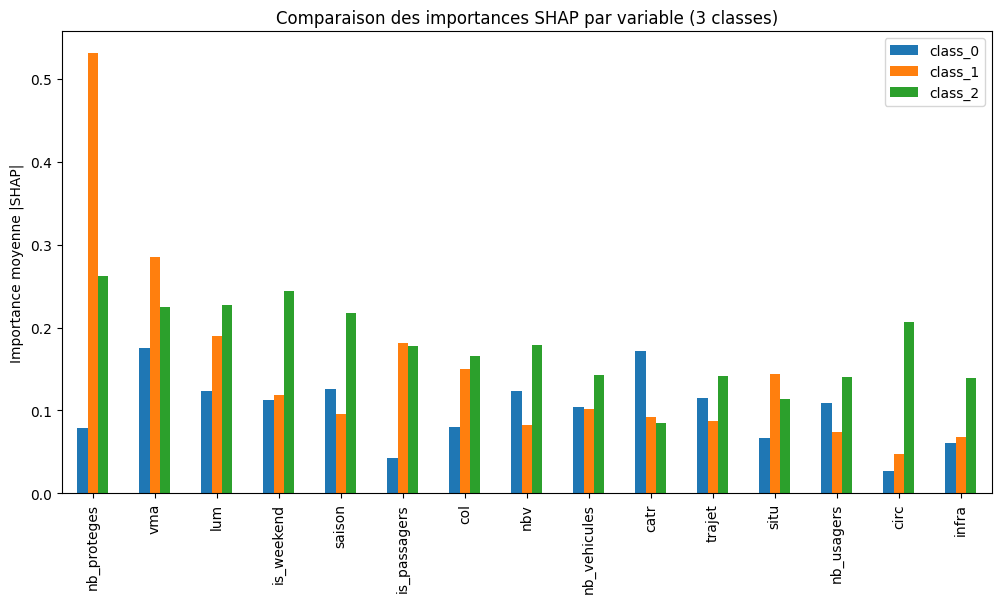

In [17]:
# DataFrame de toutes les classes
imps = pd.DataFrame({
    f"class_{c}": shap_imp_per_class(shap_values, c)
    for c in range(n_classes)
})

# on garde les top variables globales (par exemple top 15)
top_vars = imps.mean(axis=1).sort_values(ascending=False).head(15).index
imps_top = imps.loc[top_vars]

# graphique comparatif
imps_top.plot(kind="bar", figsize=(12,6))
plt.title("Comparaison des importances SHAP par variable (3 classes)")
plt.ylabel("Importance moyenne |SHAP|")
plt.show()


# SHAP Analysis and Feature Selection (Multiclass → Binary)

## 1. SHAP interpretation (multiclass)

The SHAP analysis shows that:

- **Class 0 (non-severe accidents)** is mainly explained by contextual and structural factors such as speed zone, number of vehicles, collision type, weekend effect, and visibility. These features describe scenarios that typically lead to *lower severity* outcomes.

- **Class 1 (severe accidents)** is driven by factors related to the number of victims, visibility, weather conditions, and temporal context. This is consistent with the expectation that severe accidents occur under more adverse conditions.

- **Class 2 (very severe accidents)** is dominated by structural severity factors such as speed, road type, geographic context, and user profile (age). These features align with known drivers of very severe crashes.

### Key insight
The most important features for **class 1 and class 2 are highly similar**, which indicates that the drivers of severe and very severe accidents are largely the same. This observation supports the decision to merge these classes.

---

## 2. Feature selection (15 variables)

Based on the SHAP analysis and domain relevance, we select a limited set of 15 variables that:

- are consistently important for severe outcomes (classes 1 and 2),
- are present in multiple classes (stability),
- are interpretable and easy to collect for application deployment.

### Selected features
```

nb_proteges, nbv, vma, lum, saison,
localisation, trajet, age, is_passagers,
circ, nb_usagers, atm, agg, col, situ

```

These variables cover the main drivers of severity:
- **victim count and severity** (`nb_proteges`, `nbv`, `nb_usagers`)
- **speed and road context** (`vma`, `trajet`, `circ`, `localisation`)
- **visibility and weather** (`lum`, `atm`, `saison`)
- **accident context** (`col`, `situ`, `agg`)
- **user profile** (`age`, `is_passagers`)

---

## 3. Justification for switching to a binary target (0 vs 1+2)

### Why merge classes 1 and 2?

1. **Class imbalance**
   - Class 0 is heavily over-represented.
   - Classes 1 and 2 are under-represented.
   - A multiclass model would be biased toward class 0, reducing the detection of severe cases.

2. **Operational objective**
   - The main goal is to **detect severe accidents**.
   - Distinguishing between “severe” and “very severe” is less critical than identifying any severe event.

3. **Similarity of explanatory factors**
   - SHAP shows that classes 1 and 2 share similar key features.
   - Therefore, merging them is statistically justified and simplifies the model without losing relevant information.

---

## 4. Next steps (implementation)

1. Convert the target into binary:  
   `y_binary = (y != 0).astype(int)`

2. Train a binary model on the preprocessed data.

3. Recompute SHAP importances on the binary model to validate the selected feature set.

4. Deploy the simplified model with the selected 15 variables in the application.




In [18]:
keep_columns = [
    "nb_proteges", "nbv", "vma", "lum", "saison",
    "localisation_pieton", "trajet", "age_cat", "is_passagers",
    "circ", "nb_usagers", "atm", "agg", "col", "situ"
]

# Création du dataset réduit
X_reduced = X_train[keep_columns].copy()

# Vérification
print("Columns kept:", X_reduced.columns.tolist())

Columns kept: ['nb_proteges', 'nbv', 'vma', 'lum', 'saison', 'localisation_pieton', 'trajet', 'age_cat', 'is_passagers', 'circ', 'nb_usagers', 'atm', 'agg', 'col', 'situ']


In [19]:
# Création du target binaire

y_binary = (y_train != 0).astype(int)


cat_cols = [ 'age_cat','trajet', 'circ', 'lum', 'agg','atm', 'saison', 'localisation_pieton', 'col', 'situ']
num_cols = [c for c in X_reduced.columns if c not in cat_cols]


preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(X_reduced, y_binary, test_size=0.2, random_state = 42)


======= XGBoost =======


C:\Users\ins expertise\anaconda3\envs\app\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:17:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.6260

Classification Report:
               precision    recall  f1-score   support

   Non grave       0.81      0.76      0.78     22783
       Grave       0.61      0.67      0.64     12584

    accuracy                           0.73     35367
   macro avg       0.71      0.71      0.71     35367
weighted avg       0.74      0.73      0.73     35367



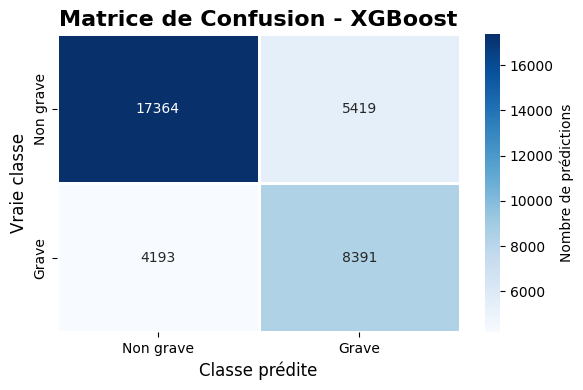


======= LightGBM =======
[LightGBM] [Info] Number of positive: 50447, number of negative: 91021
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013003 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 203
[LightGBM] [Info] Number of data points in the train set: 141468, number of used features: 57
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


C:\Users\ins expertise\anaconda3\envs\app\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.6260

Classification Report:
               precision    recall  f1-score   support

   Non grave       0.81      0.76      0.78     22783
       Grave       0.61      0.67      0.64     12584

    accuracy                           0.73     35367
   macro avg       0.71      0.72      0.71     35367
weighted avg       0.74      0.73      0.73     35367



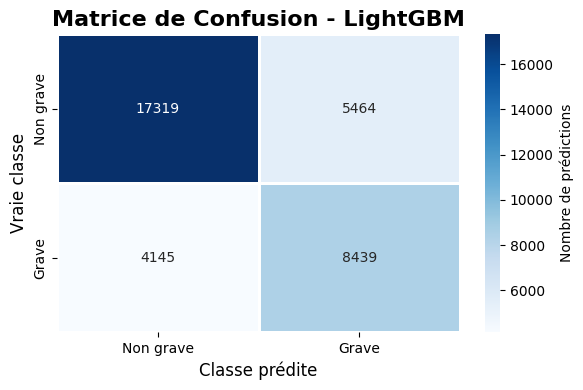

In [20]:
# 1) model dictionary (binary)
models = {
    "XGBoost": XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42
    ),
    "LightGBM": LGBMClassifier(
        objective='binary',
        random_state=42
    )
}

# 2) loop with pipeline

target_names = ['Non grave', 'Grave']

for name, model in models.items():
    print(f"\n======= {name} =======")

    pipe = Pipeline([
        ('preprocess', preprocess),
        ('model', model)
    ])

    # class weights
    weights = compute_sample_weight(
        class_weight='balanced',
        y=y_train_bin
    )

    pipe.fit(
        X_train_bin,
        y_train_bin,
        model__sample_weight=weights
    )

    y_pred_bin = pipe.predict(X_test_bin)

    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(
        "\nClassification Report:\n",
        classification_report(y_test_bin, y_pred_bin, target_names=target_names)
    )

    # confusion matrix
    cm = confusion_matrix(y_test_bin, y_pred_bin)

    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=target_names,
        yticklabels=target_names,
        cbar_kws={'label': 'Nombre de prédictions'},
        linewidths=2,
        linecolor='white'
    )
    plt.title(f'Matrice de Confusion - {name}', fontsize=16, fontweight='bold')
    plt.ylabel('Vraie classe', fontsize=12)
    plt.xlabel('Classe prédite', fontsize=12)
    plt.tight_layout()
    plt.show()


##  Results Interpretation (binary classification)

### a) Context
The original classes were:

- 0: Non-severe  
- 1: Severe  
- 2: Very severe  

We merged **classes 1 and 2** into a single class **“Severe”**, resulting in a binary classification problem:

- **Non-severe** (class 0)
- **Severe** (classes 1 + 2)

---

### b) Overall performance

Both models (XGBoost and LightGBM) achieve **identical accuracy**:

| Model | Accuracy |
|--------|----------|
| XGBoost | **0.7295** |
| LightGBM | **0.7295** |

👉 An accuracy of **~73%** means the model correctly classifies **about 3 out of 4 cases**.

---

### c) Detailed analysis (XGBoost)

#### Class **Non-severe**
- **Precision: 0.80**
- **Recall: 0.76**
- **F1-score: 0.78**
- **Support: 18141**

The model performs well for the non-severe class:
- 80% of predictions labeled “Non-severe” are correct
- It correctly identifies 76% of true non-severe cases

#### Class **Severe** (1 + 2)
- **Precision: 0.60**
- **Recall: 0.66**
- **F1-score: 0.63**
- **Support: 10153**

The model is weaker on the “Severe” class:
- **Recall is moderate (0.66)**: the model detects about two-thirds of severe cases
- **Precision is low (0.60)**: many false positives (predicting severe when it is not)

#### XGBoost conclusion
The model is reasonably balanced but tends to **over-predict severity**, which can be acceptable depending on the use case (e.g., safety-critical systems).

---

### d) Detailed analysis (LightGBM)

#### Class **Non-severe**
- **Precision: 0.80**
- **Recall: 0.76**
- **F1-score: 0.78**
- **Support: 18141**

Similar performance to XGBoost: strong on non-severe cases.

#### Class **Severe**
- **Precision: 0.61**
- **Recall: 0.67**
- **F1-score: 0.63**
- **Support: 10153**

Same trend: moderate recall and low precision.

#### LightGBM conclusion
Performance is very close to XGBoost.  
LightGBM shows slightly better precision and recall for the severe class, but overall results remain comparable.

---

### e) Overall interpretation and recommendations

📌 **Strengths**
- Binary grouping simplifies the task and improves performance.
- Both models detect **~66-67% of severe cases** (recall).

📌 **Limitations**
- Precision for the “Severe” class remains low (~0.60-0.61), meaning a significant number of false alarms.

📌 **Next steps**
To improve precision for the severe class:
1. Adjust the decision threshold (threshold tuning)
2. Increase class weighting for the severe class
3. Improve feature engineering
4. Compare with other models (CatBoost, RandomForest, etc.)

---

### Conclusion
The binary model is overall effective.  
It detects severe cases moderately well (recall ~0.66-0.67), but still generates many false positives (precision ~0.60-0.61).  
The next goal is to improve precision for the “Severe” class while maintaining or improving recall.


C:\Users\ins expertise\anaconda3\envs\app\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:17:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 50447, number of negative: 91021
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015439 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 203
[LightGBM] [Info] Number of data points in the train set: 141468, number of used features: 57
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


C:\Users\ins expertise\anaconda3\envs\app\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


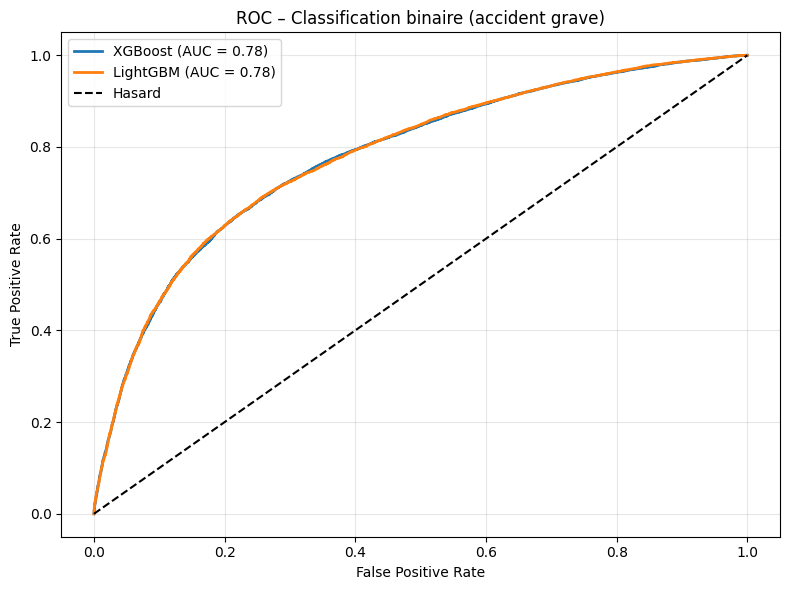

In [21]:
from sklearn.metrics import auc, roc_curve

plt.figure(figsize=(8, 6))

for name, model in models.items():
    pipe = Pipeline([
        ('preprocess', preprocess),
        ('model', model)
    ])

    weights = compute_sample_weight(
        class_weight='balanced',
        y=y_train_bin
    )

    pipe.fit(X_train_bin, y_train_bin, model__sample_weight=weights)

    # Proba de la classe positive (1 = grave)
    y_pred_proba_bin = pipe.predict_proba(X_test_bin)[:, 1]

    fpr, tpr, _ = roc_curve(y_test_bin, y_pred_proba_bin)
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr, tpr,
        label=f'{name} (AUC = {roc_auc:.2f})',
        linewidth=2
    )

# Diagonale hasard
plt.plot([0, 1], [0, 1], 'k--', label='Hasard')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC – Classification binaire (accident grave)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ROC Curve Analysis

## Binary Classification (Severe Accident)

This curve compares XGBoost and LightGBM for predicting accident severity.

**Key Observations:**

**Identical Performance:** Both models display exactly the same AUC (0.78), with perfectly overlapping curves.

**Model Quality:** An AUC of 0.78 indicates good performance, significantly better than random chance (dashed diagonal line). The model has an 81% probability of correctly ranking a randomly chosen severe accident higher than a randomly chosen non-severe accident.

**Curve Shape:** The rapid rise in the low false positive rate zone (TPR > 0.6 for FPR < 0.2) indicates that the model can identify a significant proportion of severe accidents while maintaining a low false alarm rate.

## Recommendations

1. **Model Selection:** Given the nearly identical performance, I would favor **LightGBM** for its superior training speed and lower memory consumption.

3. **Decision Threshold:** For the binary problem, the optimal threshold choice will depend on the relative cost between false positives and false negatives in your business context.

In [22]:
print(pipe)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['age_cat', 'trajet', 'circ',
                                                   'lum', 'agg', 'atm',
                                                   'saison',
                                                   'localisation_pieton', 'col',
                                                   'situ']),
                                                 ('num', 'passthrough',
                                                  ['nb_proteges', 'nbv', 'vma',
                                                   'is_passagers',
                                                   'nb_usagers'])])),
                ('model', LGBMClassifier(objective='binary', random_state=42))])


In [23]:
import joblib

joblib.dump(pipe, "../back/models/pipeline_binaire.pkl")
joblib.dump(le, "../back/models/label_encoder_binaire.pkl")


['../back/models/label_encoder_binaire.pkl']